<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/Markov_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Цепи Маркова — это математический инструмент, который может быть применен для моделирования изменения цены на финансовых рынках. Однако их прибыльность для предсказания цены (особенно на Форексе и криптовалютах) на таких таймфреймах, как M15, 1 час и 1 день, является сложным и спорным вопросом.

Вот несколько ключевых моментов для рассмотрения:

*   **Предпосылки цепей Маркова:** Цепи Маркова предполагают, что будущее состояние зависит только от текущего состояния (свойство отсутствия памяти). На финансовых рынках это не всегда так. Цены могут зависеть от множества факторов, включая макроэкономические данные, новости, настроения рынка и даже прошлые события, которые не отражены непосредственно в текущем состоянии.
*   **Эффективность рынка:** Согласно гипотезе эффективного рынка, вся доступная информация уже отражена в текущих ценах, и предсказать будущие цены на постоянной основе невозможно. Хотя на практике рынки не являются абсолютно эффективными, это делает извлечение стабильной прибыли через простые модели, такие как базовые цепи Маркова, очень сложным.
*   **Стационарность:** Цепи Маркова работают лучше, когда система является стационарной, то есть ее статистические свойства не меняются со временем. Финансовые рынки очень динамичны и нестационарны. Волатильность, корреляции и паттерны могут меняться быстро, что делает долгосрочные предсказания с использованием фиксированной марковской модели ненадежными.
*   **Сложность моделирования:** Для эффективного применения цепей Маркова к финансовым данным требуется тщательное определение состояний. Как вы будете определять «состояние» цены? Простое деление цены на диапазоны может быть слишком упрощенным. Использование более сложных метрик или технических индикаторов для определения состояний увеличивает сложность модели и требует больше данных для обучения.
*   **Шум и случайность:** Финансовые рынки содержат значительное количество случайного шума. Цепи Маркова могут улавливать некоторые паттерны, но могут также быть обмануты случайными колебаниями, что приводит к ложным сигналам.
*   **Backtesting и оптимизация:** Даже если модель цепей Маркова покажет хорошие результаты на исторических данных (backtesting), нет гарантии, что она будет прибыльной в будущем. Рынки меняются, и модель, оптимизированная под прошлые данные, может быстро перестать быть актуальной.

**Вывод:**

Хотя цепи Маркова могут быть использованы для изучения поведения цен и выявления определенных вероятностных переходов между состояниями, их **прибыльность для надежного и стабильного предсказания цены** на таких активных рынках, как Форекс и криптовалюты, на указанных таймфреймах **крайне сомнительна** для большинства трейдеров и инвесторов. Они могут быть частью более сложной торговой системы или использоваться для анализа вероятности определенных исходов, но сами по себе редко являются достаточной основой для прибыльной стратегии из-за нестационарности, шума и адаптивной природы рынков.

Чаще всего для успешной торговли требуются более сложные подходы, включающие машинное обучение, глубокое обучение, анализ настроений, фундаментальный анализ и строгие методы управления рисками, которые учитывают множество факторов, выходящих за рамки простых марковских моделей.

### Реализация простой цепи Маркова для моделирования цен

Для демонстрации концепции цепей Маркова на финансовых данных, мы создадим упрощенную модель. Мы будем использовать следующие состояния:

*   `'Up'`: Цена выросла по сравнению с предыдущим периодом.
*   `'Down'`: Цена упала по сравнению с предыдущим периодом.
*   `'Flat'`: Цена не изменилась по сравнению с предыдущим периодом.

Затем мы:
1.  **Сгенерируем синтетические данные** (или вы можете использовать свои исторические данные).
2.  **Определим состояния** на основе этих данных.
3.  **Построим матрицу переходов**, которая покажет вероятность перехода из одного состояния в другое.
4.  **Проведем симуляцию** будущих ценовых движений на основе этой матрицы.

In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

# 1. Синтетические данные о ценах
# Для простоты, сгенерируем случайные ценовые движения.
# В реальном сценарии вы бы загрузили свои исторические данные (например, CSV).

np.random.seed(42)
initial_price = 100
num_periods = 100

# Генерируем случайные изменения цены
price_changes = np.random.normal(0, 0.5, num_periods).cumsum() # Кумулятивная сумма нормального распределения
prices = initial_price + price_changes

# Создаем DataFrame
df = pd.DataFrame({'price': prices})
display(df.head())

,price
0,100.248357
1,100.179225
2,100.503069
3,101.264584
4,101.147507


In [2]:
# 2. Определение состояний рынка
# Определим состояния на основе изменения цены между периодами.

def get_state(current_price, prev_price):
    if current_price > prev_price:
        return 'Up'
    elif current_price < prev_price:
        return 'Down'
    else:
        return 'Flat'

# Применяем функцию для создания столбца состояний
states = []
for i in range(1, len(df)):
    states.append(get_state(df['price'].iloc[i], df['price'].iloc[i-1]))

# Добавляем первое состояние (можно считать его 'Flat' или 'Up'/'Down' в зависимости от первого изменения)
# Для простоты, первое состояние не имеет предыдущего, поэтому начнем с первого изменения.
# Или можем добавить 'Start' как отдельное состояние, но для Markov chain обычно нужно, чтобы все состояния были частью матрицы
# Для цепи Маркова, состояния должны быть определены для всех точек, где мы можем наблюдать переход.
# Проще всего пропустить первое, так как оно не имеет 'предыдущего' для расчета изменения.

df_states = pd.DataFrame({'state': states})
display(df_states.head())

,state
0,Down
1,Up
2,Up
3,Down
4,Down


In [3]:
# 3. Построение матрицы переходов

# Список уникальных состояний
possible_states = ['Up', 'Down', 'Flat']

# Инициализируем матрицу переходов нулями
transition_matrix = pd.DataFrame(0, index=possible_states, columns=possible_states)

# Заполняем матрицу, подсчитывая переходы
for i in range(len(df_states) - 1):
    current_state = df_states['state'].iloc[i]
    next_state = df_states['state'].iloc[i+1]
    transition_matrix.loc[current_state, next_state] += 1

# Нормализуем строки для получения вероятностей
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

display(transition_matrix)

# Обработка случаев, когда сумма по строке равна 0 (т.е., состояние ни разу не встречалось)
# В этом случае, можно присвоить равномерное распределение или 0 для всех переходов
transition_matrix = transition_matrix.fillna(0)
display(transition_matrix)

,Up,Down,Flat
Up,0.400000,0.600000,0.0
Down,0.509434,0.490566,0.0
Flat,NaN,NaN,NaN


,Up,Down,Flat
Up,0.400000,0.600000,0.0
Down,0.509434,0.490566,0.0
Flat,0.000000,0.000000,0.0


In [4]:
# 4. Симуляция с использованием матрицы переходов

def simulate_markov_chain(transition_matrix, start_state, num_steps):
    current_state = start_state
    simulation = [current_state]
    for _ in range(num_steps - 1):
        # Выбираем следующее состояние на основе вероятностей текущего состояния
        next_state = np.random.choice(transition_matrix.columns,
                                      p=transition_matrix.loc[current_state])
        simulation.append(next_state)
        current_state = next_state
    return simulation

# Задаем начальное состояние и количество шагов симуляции
start_state = random.choice(possible_states) # Начнем со случайного состояния
num_simulation_steps = 50

simulated_path = simulate_markov_chain(transition_matrix, start_state, num_simulation_steps)
print(f"Начальное состояние: {start_state}")
print(f"Сгенерированный путь состояний: {simulated_path}")

Начальное состояние: Down
Сгенерированный путь состояний: ['Down', 'Up', 'Up', 'Up', 'Up', 'Down', 'Up', 'Down', 'Down', 'Up', 'Down', 'Down', 'Up', 'Down', 'Up', 'Up', 'Up', 'Down', 'Up', 'Up', 'Up', 'Down', 'Up', 'Up', 'Down', 'Down', 'Up', 'Down', 'Down', 'Up', 'Down', 'Up', 'Down', 'Down', 'Down', 'Up', 'Down', 'Up', 'Up', 'Up', 'Down', 'Down', 'Up', 'Down', 'Up', 'Down', 'Up', 'Down', 'Up', 'Down']


### Визуализация симуляции цепи Маркова

Теперь мы можем визуализировать сгенерированный путь состояний, чтобы увидеть, как модель предсказывает изменения рынка на основе исторических переходов.

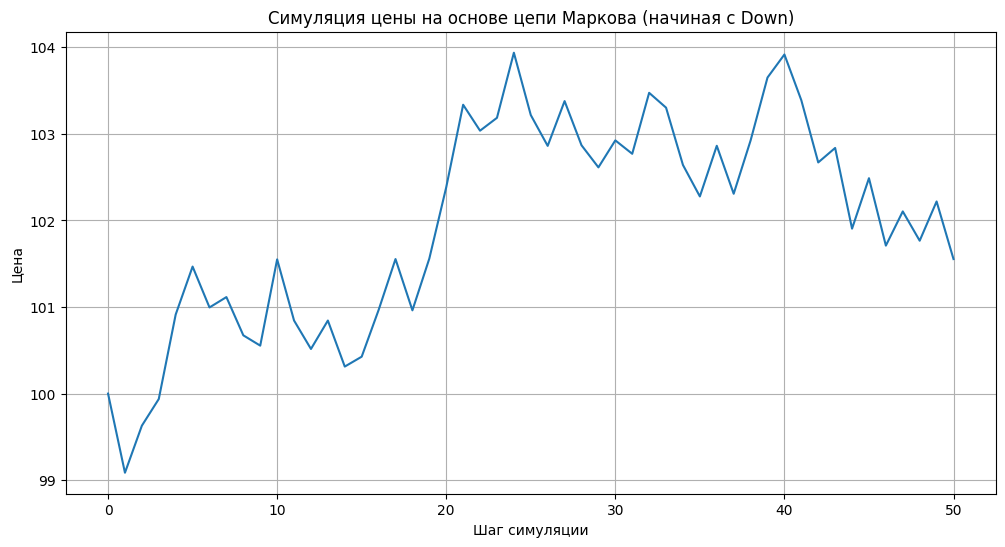

In [5]:
state_to_value = {'Up': 1, 'Down': -1, 'Flat': 0}
price_simulation = [initial_price] # Начинаем с исходной цены

for state in simulated_path:
    if state == 'Up':
        price_simulation.append(price_simulation[-1] * (1 + random.uniform(0.001, 0.01))) # Небольшой рост
    elif state == 'Down':
        price_simulation.append(price_simulation[-1] * (1 - random.uniform(0.001, 0.01))) # Небольшое падение
    else:
        price_simulation.append(price_simulation[-1]) # Цена не меняется

plt.figure(figsize=(12, 6))
plt.plot(price_simulation)
plt.title(f'Симуляция цены на основе цепи Маркова (начиная с {start_state})')
plt.xlabel('Шаг симуляции')
plt.ylabel('Цена')
plt.grid(True)
plt.show()

### Backtesting Markov Model with (Simulated) Historical Data

For a more robust evaluation, we'll perform a basic backtest. This involves:
1.  Generating a longer, more complex simulated historical price series.
2.  Splitting this data into training and testing sets.
3.  Building the Markov transition matrix *only* from the training data.
4.  Simulating price movements for the test period based on the last state of the training period.
5.  Comparing the simulated path with the actual (simulated) path in the test set.

--- Generating new simulated historical data for backtesting ---


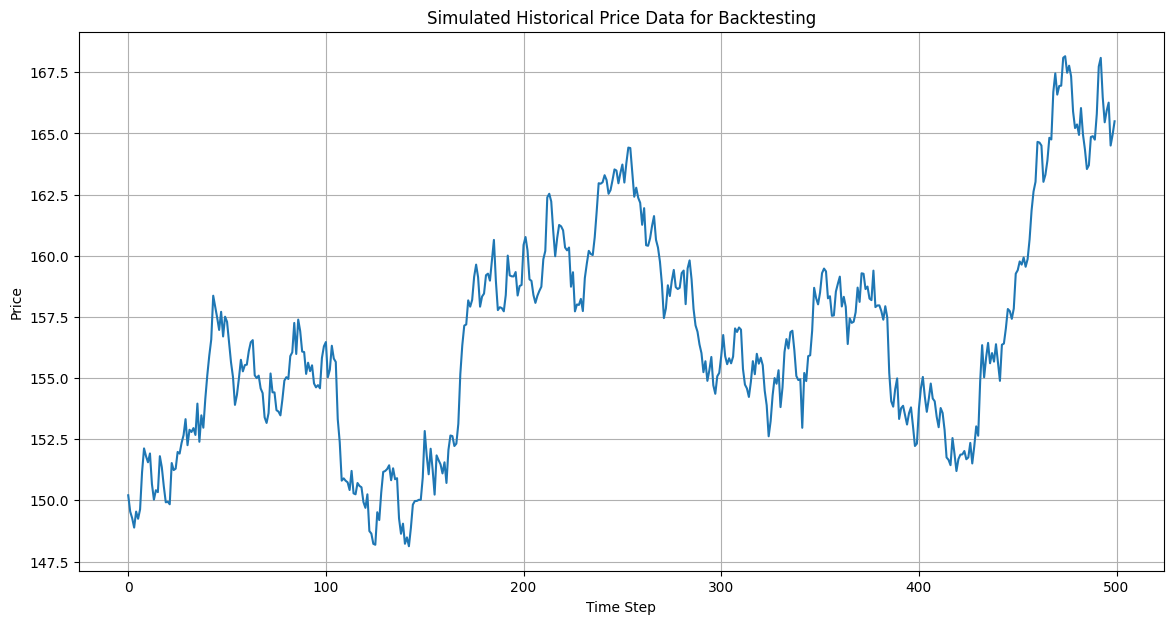

,price
0,150.208050
1,149.540765
2,149.272710
3,148.888396
4,149.542071


In [6]:
print('--- Generating new simulated historical data for backtesting ---')

np.random.seed(43) # Different seed for new data
initial_price_bt = 150
num_periods_bt = 500 # More periods for backtesting

# Generate price changes with a slight upward drift for more 'realism'
daily_returns = np.random.normal(0.0001, 0.005, num_periods_bt) # Mean of 0.01% daily return, 0.5% std dev
price_series_bt = initial_price_bt * (1 + daily_returns).cumprod()

df_bt = pd.DataFrame({'price': price_series_bt})

plt.figure(figsize=(14, 7))
plt.plot(df_bt['price'])
plt.title('Simulated Historical Price Data for Backtesting')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.grid(True)
plt.show()

display(df_bt.head())

In [7]:
print('--- Defining states for the new historical data ---')

states_bt = []
for i in range(1, len(df_bt)):
    states_bt.append(get_state(df_bt['price'].iloc[i], df_bt['price'].iloc[i-1]))

df_states_bt = pd.DataFrame({'state': states_bt})
display(df_states_bt.head())

--- Defining states for the new historical data ---


,state
0,Down
1,Down
2,Down
3,Up
4,Down


In [8]:
print('--- Splitting data into training and testing sets ---')

train_size = int(len(df_bt) * 0.7) # 70% for training

df_train = df_bt.iloc[:train_size].copy()
df_test = df_bt.iloc[train_size:].copy()

df_states_train = df_states_bt.iloc[:train_size - 1].copy() # states are one shorter than prices
df_states_test = df_states_bt.iloc[train_size - 1:].copy() # test states start from last train price change

print(f'Training data length: {len(df_train)} periods')
print(f'Testing data length: {len(df_test)} periods')
print(f'Training states length: {len(df_states_train)}')
print(f'Testing states length: {len(df_states_test)}')

# The state of the last price in the training set is crucial for starting the test simulation
last_train_state = df_states_train.iloc[-1]['state']
print(f'Last state in training set (for starting test simulation): {last_train_state}')

--- Splitting data into training and testing sets ---
Training data length: 350 periods
Testing data length: 150 periods
Training states length: 349
Testing states length: 150
Last state in training set (for starting test simulation): Down


In [9]:
print('--- Building transition matrix from training data ---')

transition_matrix_bt = pd.DataFrame(0, index=possible_states, columns=possible_states)

for i in range(len(df_states_train) - 1):
    current_state = df_states_train['state'].iloc[i]
    next_state = df_states_train['state'].iloc[i+1]
    transition_matrix_bt.loc[current_state, next_state] += 1

transition_matrix_bt = transition_matrix_bt.div(transition_matrix_bt.sum(axis=1), axis=0)
transition_matrix_bt = transition_matrix_bt.fillna(0) # Handle states that might not have appeared

display(transition_matrix_bt)

--- Building transition matrix from training data ---


,Up,Down,Flat
Up,0.497110,0.502890,0.0
Down,0.497143,0.502857,0.0
Flat,0.000000,0.000000,0.0


--- Simulating price movements for the test period ---
Simulated states for test period (150 steps): ['Down', 'Down', 'Up', 'Down', 'Up', 'Down', 'Down', 'Down', 'Up', 'Down']...['Up', 'Up', 'Up', 'Up', 'Down', 'Up', 'Up', 'Down', 'Up', 'Down']


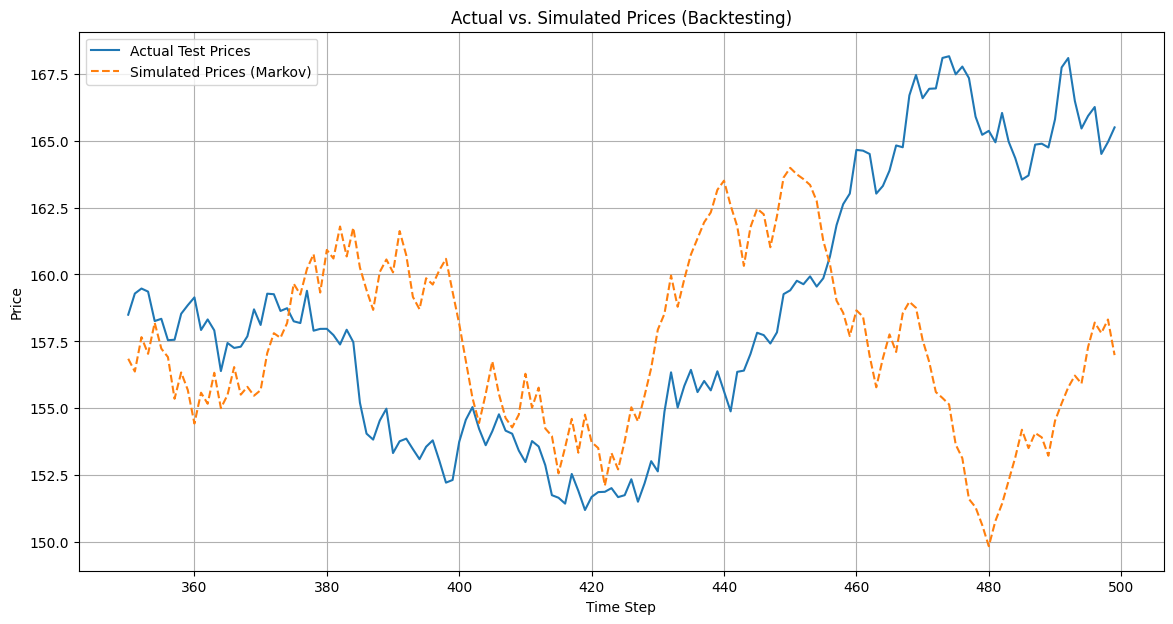

In [10]:
print('--- Simulating price movements for the test period ---')

num_simulation_steps_bt = len(df_test) # Simulate for the length of the test set

simulated_path_bt = simulate_markov_chain(transition_matrix_bt, last_train_state, num_simulation_steps_bt)
print(f"Simulated states for test period ({len(simulated_path_bt)} steps): {simulated_path_bt[:10]}...{simulated_path_bt[-10:]}")

# Reconstruct price from simulated states
price_simulation_bt = [df_train.iloc[-1]['price']] # Start from the last price of the training set

for state in simulated_path_bt:
    if state == 'Up':
        price_simulation_bt.append(price_simulation_bt[-1] * (1 + random.uniform(0.001, 0.01)))
    elif state == 'Down':
        price_simulation_bt.append(price_simulation_bt[-1] * (1 - random.uniform(0.001, 0.01)))
    else:
        price_simulation_bt.append(price_simulation_bt[-1])

# Ensure price_simulation_bt has the same length as df_test for plotting comparison
# (num_simulation_steps_bt + 1 as it includes initial price)
price_simulation_bt = price_simulation_bt[:len(df_test) + 1]

plt.figure(figsize=(14, 7))
plt.plot(df_test.index, df_test['price'], label='Actual Test Prices')
plt.plot(df_test.index, price_simulation_bt[1:], label='Simulated Prices (Markov)', linestyle='--') # Skip first sim price
plt.title('Actual vs. Simulated Prices (Backtesting)')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
print('--- Calculating accuracy of simulated states vs actual states ---')

# Actual states in the test set (from df_states_test)
actual_states_test = df_states_test['state'].tolist()

# Simulated states for the test period (from simulated_path_bt)
# Ensure both lists are of the same length for comparison
# The simulated_path_bt is already generated for len(df_test) periods
# df_states_test is also len(df_test) periods long

# Calculate accuracy
correct_predictions = 0
for i in range(len(actual_states_test)):
    if i < len(simulated_path_bt) and actual_states_test[i] == simulated_path_bt[i]:
        correct_predictions += 1

accuracy = correct_predictions / len(actual_states_test)

print(f'Total actual test states: {len(actual_states_test)}')
print(f'Total simulated test states: {len(simulated_path_bt)}')
print(f'Number of correct state predictions: {correct_predictions}')
print(f'Accuracy of state prediction: {accuracy:.2f}')

--- Calculating accuracy of simulated states vs actual states ---
Total actual test states: 150
Total simulated test states: 150
Number of correct state predictions: 80
Accuracy of state prediction: 0.53


### Interpretation and Limitations of Backtesting

This simple backtest demonstrates how a Markov model, trained on past data, can generate future price scenarios. However, it's crucial to understand its limitations:

*   **Simplistic States:** 'Up', 'Down', 'Flat' are very basic. Real market conditions are far more nuanced.
*   **Synthetic Data:** We used simulated data. Real market data exhibits complex, non-linear dependencies, fat tails, and regime changes that a simple Markov model often cannot capture.
*   **No Trading Strategy:** This backtest only compares price paths, not actual trading performance (profit/loss, drawdowns, etc.). A real backtest would involve defining entry/exit rules based on the Markov state predictions.
*   **Efficiency of Markets:** As discussed previously, financial markets tend to be efficient, making simple predictive models unreliable over the long term.
*   **Stationarity Assumption:** The Markov chain assumes stationarity in transition probabilities, which is rarely true for dynamic financial markets. Probabilities change as market conditions evolve.

More advanced backtesting would involve more sophisticated state definitions, considering multiple factors (volume, volatility, indicators), dynamic recalibration of the transition matrix, and rigorous statistical evaluation of trading strategies built upon the model.

### Проверка работы цепи Маркова на реальных финансовых данных

Для проверки модели на реальных данных, нам потребуется загрузить исторические данные для указанных инструментов (EURUSD, GBPUSD, USDCHF, DXY) и таймфреймов (M15, 1 час, 1 день (1440 минут)).

**Важно:**
*   Для Forex данных высокой точности и специфических таймфреймов часто требуются специализированные API или загрузка CSV-файлов от брокеров (например, Alpari, Oanda, Dukascopy).
*   `yfinance` может быть использован для демонстрации, но его Forex-данные не всегда идеальны для краткосрочных стратегий.

In [13]:
import yfinance as yf
import datetime

# --- Параметры для загрузки данных ---
instruments = ['EURUSD=X', 'GBPUSD=X', 'USDCHF=X'] # Для DXY нет прямого тикера в yfinance, нужно будет искать альтернативу или использовать ETF
timeframes = {'15m': '15m', '1h': '60m', '1d': '1d'} # yfinance uses different interval names

# Определим период для загрузки данных
end_date = datetime.date.today()

all_data = {}

print("--- Загрузка исторических данных ---")

for instrument in instruments:
    print(f"Загрузка данных для {instrument}...")
    data_for_instrument = {}
    for tf_name, tf_interval in timeframes.items():
        current_start_date = end_date
        if tf_name == '15m':
            current_start_date = end_date - datetime.timedelta(days=59) # ~60 days for 15m data
        elif tf_name == '1h':
            current_start_date = end_date - datetime.timedelta(days=729) # ~2 years for 1h data
        elif tf_name == '1d':
            current_start_date = end_date - datetime.timedelta(days=365) # 1 year for 1d data

        try:
            df_temp = yf.download(instrument, start=current_start_date, end=end_date, interval=tf_interval)
            if not df_temp.empty:
                data_for_instrument[tf_name] = df_temp[['Open', 'High', 'Low', 'Close', 'Volume']]
                print(f"  {tf_name}: Загружено {len(df_temp)} записей (с {current_start_date}).")
            else:
                print(f"  {tf_name}: Данные не найдены или пустые (с {current_start_date}).")
        except Exception as e:
            print(f"  Ошибка при загрузке {tf_name} для {instrument} (с {current_start_date}): {e}")
    all_data[instrument] = data_for_instrument

# Пример отображения данных для EURUSD 1h
if 'EURUSD=X' in all_data and '1h' in all_data['EURUSD=X']:
    print("\n--- Пример данных EURUSD (1h) ---")
    display(all_data['EURUSD=X']['1h'].head())
else:
    print("\nДанные EURUSD (1h) не были загружены успешно.")

# Для DXY (индекс доллара) yfinance не предоставляет прямой тикер.
# Часто используют фьючерсы на DXY (DX=F) или ETF, такие как UUP, но они не являются прямым DXY.
# Для простоты, мы пропустим DXY в этом примере, если у вас нет готовых данных.

--- Загрузка исторических данных ---
Загрузка данных для EURUSD=X...


/tmp/ipykernel_1998/2756166972.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(instrument, start=current_start_date, end=end_date, interval=tf_interval)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1998/2756166972.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(instrument, start=current_start_date, end=end_date, interval=tf_interval)


  15m: Загружено 4031 записей (с 2026-03-09).


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1998/2756166972.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(instrument, start=current_start_date, end=end_date, interval=tf_interval)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1998/2756166972.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(instrument, start=current_start_date, end=end_date, interval=tf_interval)


  1h: Загружено 12296 записей (с 2024-05-08).
  1d: Загружено 259 записей (с 2025-05-07).
Загрузка данных для GBPUSD=X...


...

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1998/2756166972.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(instrument, start=current_start_date, end=end_date, interval=tf_interval)


  15m: Загружено 4024 записей (с 2026-03-09).


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1998/2756166972.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(instrument, start=current_start_date, end=end_date, interval=tf_interval)
[*********************100%***********************]  1 of 1 completed

  1h: Загружено 12253 записей (с 2024-05-08).
  1d: Загружено 259 записей (с 2025-05-07).

--- Пример данных EURUSD (1h) ---


Price,Open,High,Low,Close,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Datetime,,,,,
2024-05-07 23:00:00+00:00,1.075384,1.075384,1.075038,1.075269,0
2024-05-08 00:00:00+00:00,1.075384,1.075732,1.075038,1.075038,0
2024-05-08 01:00:00+00:00,1.075038,1.075038,1.074460,1.074576,0
2024-05-08 02:00:00+00:00,1.074345,1.074576,1.074114,1.074460,0
2024-05-08 03:00:00+00:00,1.074460,1.074576,1.074229,1.074460,0


### Построение матриц переходов для реальных финансовых данных

Теперь, когда у нас есть реальные исторические данные, мы можем применить тот же процесс:
1.  **Определение состояний**: Использование 'Up', 'Down', 'Flat' на основе изменения цены закрытия.
2.  **Построение матрицы переходов**: Подсчет переходов и нормализация для получения вероятностей.

In [15]:
# 2. Определение состояний рынка для реальных данных

def get_state_real_data(current_price, prev_price, threshold=0):
    if current_price > prev_price + threshold:
        return 'Up'
    elif current_price < prev_price - threshold:
        return 'Down'
    else:
        return 'Flat'

# Словарь для хранения матриц переходов для каждого инструмента и таймфрейма
all_transition_matrices = {}

print("--- Построение матриц переходов ---")

for instrument, tfs_data in all_data.items():
    all_transition_matrices[instrument] = {}
    print(f"Обработка {instrument}...")
    for tf_name, df_data in tfs_data.items():
        if not df_data.empty:
            # Используем столбец 'Close' для определения состояний
            states_real = []
            for i in range(1, len(df_data)):
                states_real.append(get_state_real_data(df_data['Close'].iloc[i].item(), df_data['Close'].iloc[i-1].item()))

            # Создаем DataFrame для состояний
            df_states_real = pd.DataFrame({'state': states_real})

            # 3. Построение матрицы переходов
            transition_matrix_real = pd.DataFrame(0, index=possible_states, columns=possible_states)

            for i in range(len(df_states_real) - 1):
                current_state = df_states_real['state'].iloc[i]
                next_state = df_states_real['state'].iloc[i+1]
                transition_matrix_real.loc[current_state, next_state] += 1

            # Нормализуем строки для получения вероятностей
            transition_matrix_real = transition_matrix_real.div(transition_matrix_real.sum(axis=1), axis=0)
            transition_matrix_real = transition_matrix_real.fillna(0) # Заполняем NaN, если состояние не встречалось

            all_transition_matrices[instrument][tf_name] = transition_matrix_real
            print(f"  {tf_name}: Матрица переходов построена.")
        else:
            print(f"  {tf_name}: Данные отсутствуют для {instrument}, матрица не построена.")

# Пример отображения матрицы переходов для EURUSD 1h
print("\n--- Пример матрицы переходов для EURUSD (1h) ---")
if 'EURUSD=X' in all_transition_matrices and '1h' in all_transition_matrices['EURUSD=X']:
    display(all_transition_matrices['EURUSD=X']['1h'])
else:
    print("Матрица переходов для EURUSD (1h) не была построена успешно.")

--- Построение матриц переходов ---
Обработка EURUSD=X...
  15m: Матрица переходов построена.
  1h: Матрица переходов построена.
  1d: Матрица переходов построена.
Обработка GBPUSD=X...
  15m: Матрица переходов построена.
  1h: Матрица переходов построена.
  1d: Матрица переходов построена.
Обработка USDCHF=X...
  15m: Матрица переходов построена.
  1h: Матрица переходов построена.
  1d: Матрица переходов построена.

--- Пример матрицы переходов для EURUSD (1h) ---


,Up,Down,Flat
Up,0.444523,0.471728,0.083748
Down,0.473366,0.447621,0.079013
Flat,0.442197,0.440270,0.117534


### Симуляция будущей цены для GBPUSD (1h) на основе цепи Маркова

Теперь, когда у нас есть матрицы переходов для реальных данных, мы можем использовать их для симуляции будущих ценовых движений. Мы возьмем матрицу для GBPUSD, таймфрейм 1 час.

Начальное состояние для GBPUSD (1h) симуляции: Up
Сгенерированный путь состояний для GBPUSD (1h): ['Up', 'Up', 'Down', 'Up', 'Up', 'Down', 'Up', 'Up', 'Down', 'Up']...['Up', 'Down', 'Up', 'Up', 'Up', 'Down', 'Up', 'Up', 'Up', 'Down']


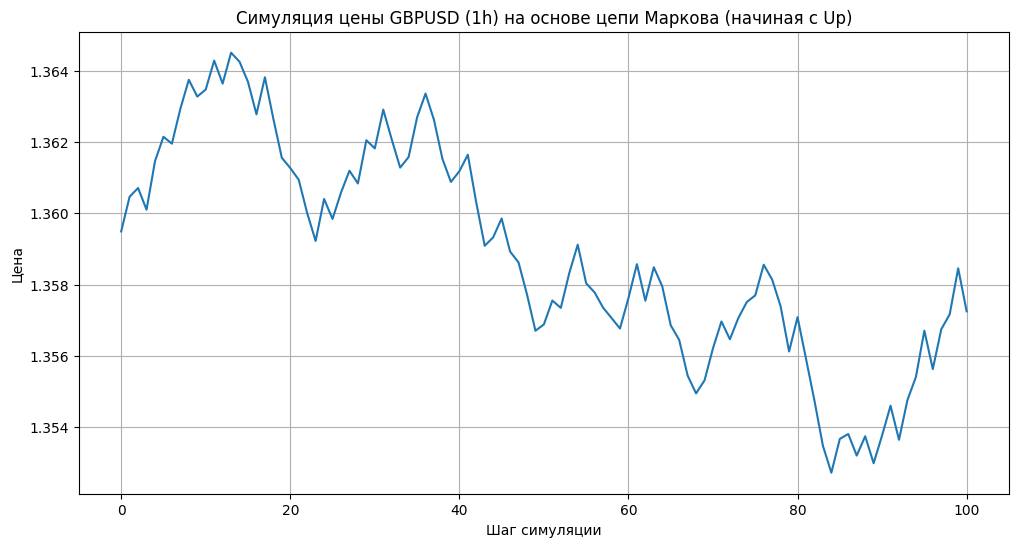

In [16]:
# 4. Симуляция с использованием матрицы переходов для GBPUSD (1h)

transition_matrix_gbpusd_1h = all_transition_matrices['GBPUSD=X']['1h']
df_gbpusd_1h = all_data['GBPUSD=X']['1h']

# Определим начальное состояние для симуляции
# Для этого возьмем последнее состояние из исторических данных GBPUSD 1h
last_close_gbpusd_1h = df_gbpusd_1h['Close'].iloc[-1].item()
prev_close_gbpusd_1h = df_gbpusd_1h['Close'].iloc[-2].item()
start_state_gbpusd_1h = get_state_real_data(last_close_gbpusd_1h, prev_close_gbpusd_1h)

num_simulation_steps_gbpusd = 100 # Симулируем 100 шагов вперед

simulated_path_gbpusd_1h = simulate_markov_chain(transition_matrix_gbpusd_1h, start_state_gbpusd_1h, num_simulation_steps_gbpusd)

print(f"Начальное состояние для GBPUSD (1h) симуляции: {start_state_gbpusd_1h}")
print(f"Сгенерированный путь состояний для GBPUSD (1h): {simulated_path_gbpusd_1h[:10]}...{simulated_path_gbpusd_1h[-10:]}")

# Реконструкция цены из симулированных состояний
price_simulation_gbpusd = [last_close_gbpusd_1h] # Начинаем с последней реальной цены

for state in simulated_path_gbpusd_1h:
    if state == 'Up':
        price_simulation_gbpusd.append(price_simulation_gbpusd[-1] * (1 + random.uniform(0.0001, 0.001))) # Небольшой рост
    elif state == 'Down':
        price_simulation_gbpusd.append(price_simulation_gbpusd[-1] * (1 - random.uniform(0.0001, 0.001))) # Небольшое падение
    else:
        price_simulation_gbpusd.append(price_simulation_gbpusd[-1]) # Цена не меняется

plt.figure(figsize=(12, 6))
plt.plot(price_simulation_gbpusd)
plt.title(f'Симуляция цены GBPUSD (1h) на основе цепи Маркова (начиная с {start_state_gbpusd_1h})')
plt.xlabel('Шаг симуляции')
plt.ylabel('Цена')
plt.grid(True)
plt.show()

### Сравнение симулированного ценового пути с фактическими историческими тенденциями GBPUSD

Теперь давайте сравним сгенерированный симулированный ценовой путь с недавними фактическими историческими данными GBPUSD, чтобы визуально оценить их расхождение.

### Оценка прибыльности на основе симуляции Марковской цепи

Чтобы оценить потенциальную прибыльность, мы можем применить простую торговую стратегию к симулированным состояниям и сравнить ее с фактическими движениями цены на реальных котировках. Мы будем использовать данные GBPUSD (1h).

**Простая стратегия:**
*   Если модель предсказывает 'Up', мы совершаем покупку и удерживаем позицию до следующего периода.
*   Если модель предсказывает 'Down', мы совершаем продажу и удерживаем позицию до следующего периода.
*   Если модель предсказывает 'Flat', мы остаемся вне рынка.

--- Оценка прибыльности для GBPUSD (1h) ---
Общий P&L за 99 сделок: -0.00375
Количество сделок: 99
Количество прибыльных сделок: 44
Процент прибыльных сделок: 44.44%


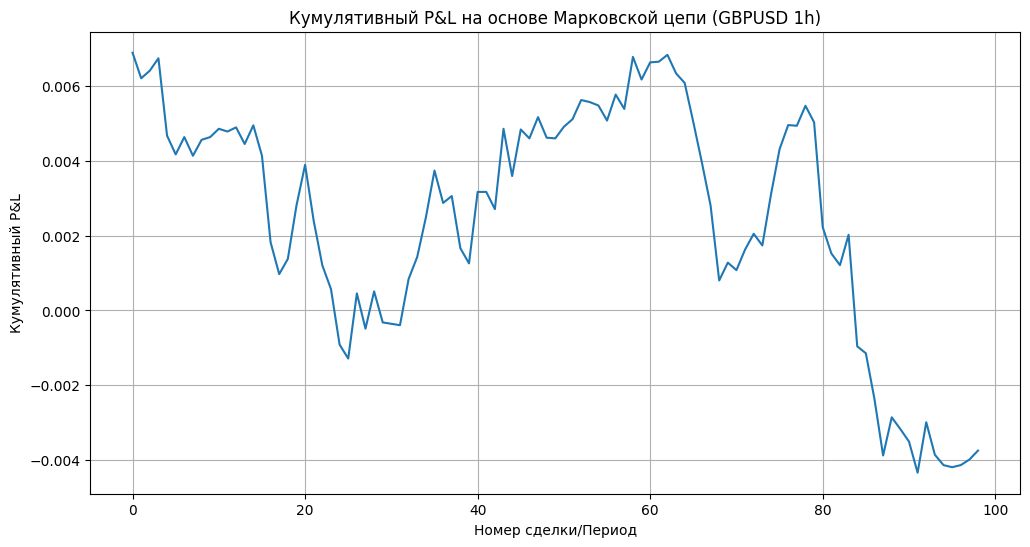

In [20]:
print("--- Оценка прибыльности для GBPUSD (1h) ---")

transition_matrix_gbpusd_1h = all_transition_matrices['GBPUSD=X']['1h']
df_gbpusd_1h = all_data['GBPUSD=X']['1h']

# Определим данные для бэктестинга (возьмем последний сегмент исторических данных)
# Для простоты, используем тот же период, что и для визуального сравнения
num_periods_for_backtest = num_simulation_steps_gbpusd # 100 периодов вперед от последней исторической точки

# Фактические цены за период бэктеста
actual_prices_for_backtest = df_gbpusd_1h['Close'].iloc[-num_periods_for_backtest-1:].copy().reset_index(drop=True)

# Фактические состояния за период бэктеста
actual_states_for_backtest = []
for i in range(1, len(actual_prices_for_backtest)):
    actual_states_for_backtest.append(get_state_real_data(actual_prices_for_backtest.iloc[i].item(), actual_prices_for_backtest.iloc[i-1].item()))

# Начальное состояние для симуляции (то же, что и для предыдущей симуляции)
start_state_gbpusd_1h_bt = get_state_real_data(df_gbpusd_1h['Close'].iloc[-1].item(), df_gbpusd_1h['Close'].iloc[-2].item())

# Симулируем состояния на основе матрицы переходов
simulated_states_for_backtest = simulate_markov_chain(transition_matrix_gbpusd_1h, start_state_gbpusd_1h_bt, num_periods_for_backtest)

# --- Расчет P&L и метрик ----
total_pnl = 0
num_trades = 0
num_winning_trades = 0

# Начинаем со второй точки, так как первое "состояние" относится к переходу между 0 и 1 точками
for i in range(len(simulated_states_for_backtest) - 1):
    predicted_state = simulated_states_for_backtest[i]

    # Фактическое изменение цены в следующем периоде (с t+1 по t+2)
    # Здесь важно: actual_prices_for_backtest[i+1] - это цена на конец текущего периода,
    # а actual_prices_for_backtest[i+2] - цена на конец следующего периода
    # Соответственно, изменение actual_prices_for_backtest[i+1] -> actual_prices_for_backtest[i+2]
    # соответствует predicted_state[i+1]

    # Мы будем использовать actual_prices_for_backtest[i+1] в качестве точки входа, а actual_prices_for_backtest[i+2] как точку выхода
    # Поэтому нам нужно, чтобы actual_prices_for_backtest был достаточно длинным.

    if i + 2 >= len(actual_prices_for_backtest): # Убедимся, что у нас есть следующая точка для расчета P&L
        break

    entry_price = actual_prices_for_backtest.iloc[i+1].item()
    exit_price = actual_prices_for_backtest.iloc[i+2].item()

    trade_pnl = 0
    if predicted_state == 'Up':
        # Покупка (Buy)
        trade_pnl = (exit_price - entry_price)
        num_trades += 1
    elif predicted_state == 'Down':
        # Продажа (Sell)
        trade_pnl = (entry_price - exit_price)
        num_trades += 1
    # Если 'Flat', P&L = 0, num_trades не увеличивается

    total_pnl += trade_pnl
    if trade_pnl > 0:
        num_winning_trades += 1

win_rate = (num_winning_trades / num_trades) * 100 if num_trades > 0 else 0

print(f"Общий P&L за {num_trades} сделок: {total_pnl:.5f}")
print(f"Количество сделок: {num_trades}")
print(f"Количество прибыльных сделок: {num_winning_trades}")
print(f"Процент прибыльных сделок: {win_rate:.2f}%")

# Визуализация P&L (кумулятивный)
cumulative_pnl = np.cumsum([((actual_prices_for_backtest.iloc[j+2].item() - actual_prices_for_backtest.iloc[j+1].item()) if simulated_states_for_backtest[j] == 'Up'
                             else (actual_prices_for_backtest.iloc[j+1].item() - actual_prices_for_backtest.iloc[j+2].item()) if simulated_states_for_backtest[j] == 'Down'
                             else 0)
                            for j in range(len(simulated_states_for_backtest) - 1)
                            if j + 2 < len(actual_prices_for_backtest)
                           ])

plt.figure(figsize=(12, 6))
plt.plot(cumulative_pnl)
plt.title('Кумулятивный P&L на основе Марковской цепи (GBPUSD 1h)')
plt.xlabel('Номер сделки/Период')
plt.ylabel('Кумулятивный P&L')
plt.grid(True)
plt.show()

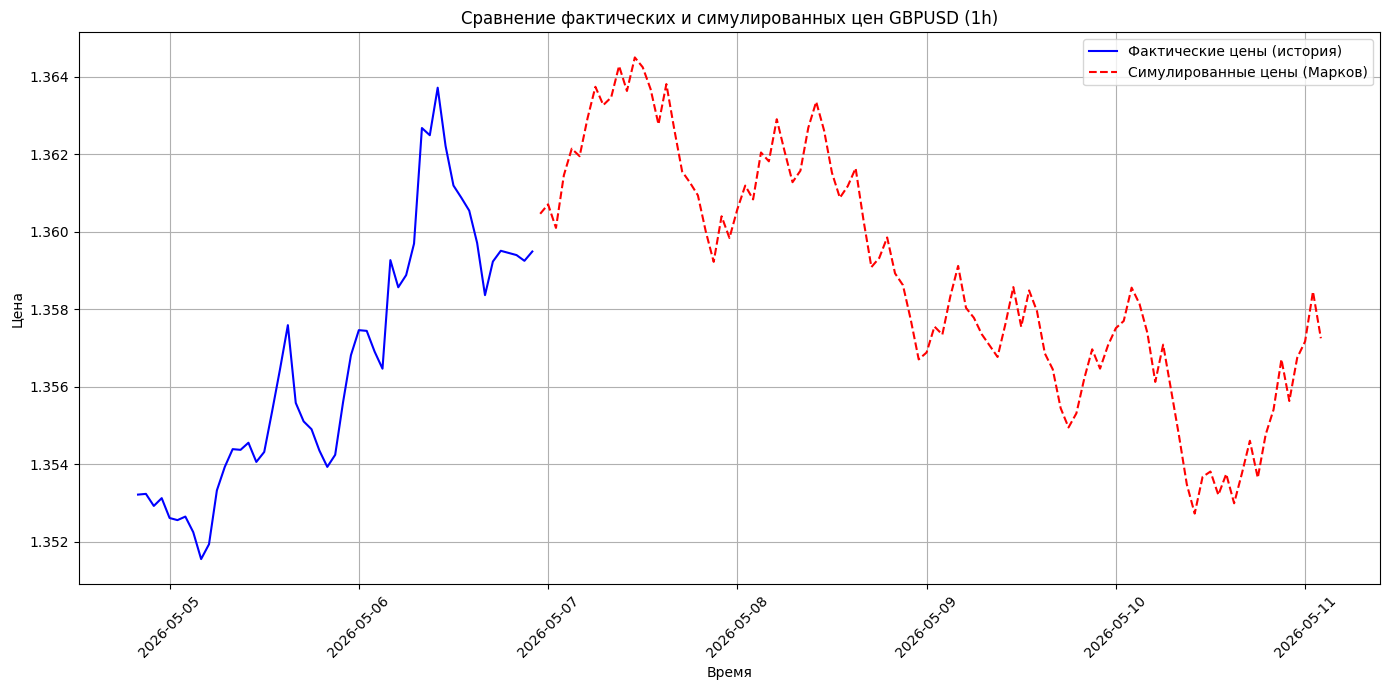

In [17]:
plt.figure(figsize=(14, 7))

# Количество точек исторической цены для отображения вместе с симуляцией
num_recent_history_points = 50

# Фактические исторические цены (последние num_recent_history_points и последняя точка перед симуляцией)
actual_history_to_plot = df_gbpusd_1h['Close'].iloc[-num_recent_history_points-1:].copy()

# Индекс для исторических данных
actual_history_index = actual_history_to_plot.index

# Индекс для симулированных данных, продолжающий исторический
# Мы начинаем симуляцию после последней исторической точки
last_historical_timestamp = actual_history_index[-1]

# Создадим временной ряд, начиная со следующего часа после последней исторической точки
simulated_index = pd.date_range(start=last_historical_timestamp + pd.Timedelta(hours=1),
                                 periods=num_simulation_steps_gbpusd,
                                 freq='h')

# Построение графиков
plt.plot(actual_history_index, actual_history_to_plot, label='Фактические цены (история)', color='blue')
plt.plot(simulated_index, price_simulation_gbpusd[1:], label='Симулированные цены (Марков)', linestyle='--', color='red')

plt.title('Сравнение фактических и симулированных цен GBPUSD (1h)')
plt.xlabel('Время')
plt.ylabel('Цена')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()